In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['flower_name'] = [iris.target_names[t] for t in iris.target]


df = df[['petal length (cm)', 'petal width (cm)', 'flower_name']]
df.head()

,petal length (cm),petal width (cm),flower_name
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


Text(0, 0.5, 'Petal Width (cm)')

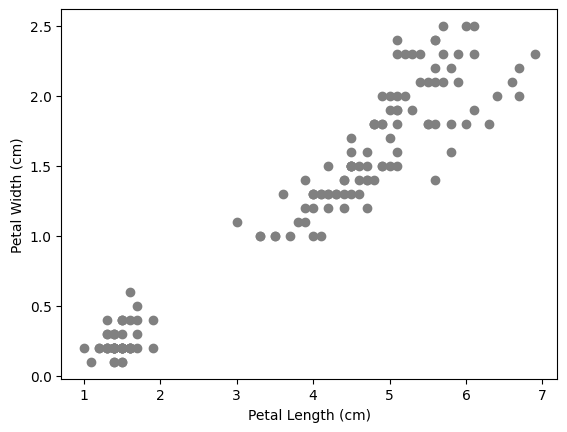

In [3]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], color='gray')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

In [4]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [5]:
df['cluster'] = y_predicted
df.head()

,petal length (cm),petal width (cm),flower_name,cluster
0,1.4,0.2,setosa,0
1,1.4,0.2,setosa,0
2,1.3,0.2,setosa,0
3,1.5,0.2,setosa,0
4,1.4,0.2,setosa,0


In [6]:
km.cluster_centers_

array([[1.462     , 0.246     ],
       [5.59583333, 2.0375    ],
       [4.26923077, 1.34230769]])

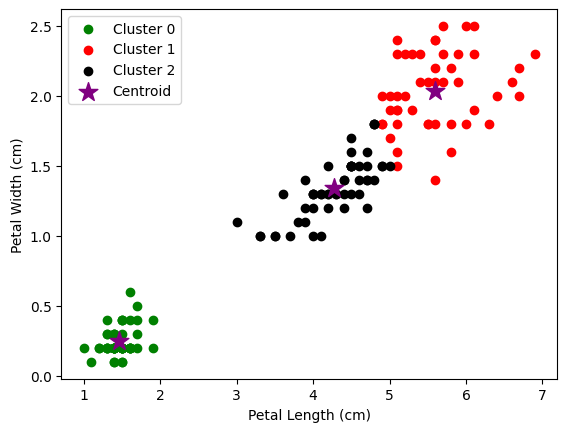

In [7]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='green', label='Cluster 0')
plt.scatter(df2['petal length (cm)'], df2['petal width (cm)'], color='red', label='Cluster 1')
plt.scatter(df3['petal length (cm)'], df3['petal width (cm)'], color='black', label='Cluster 2')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            color='purple', marker='*', s=200, label='Centroid')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()

In [8]:
scaler = MinMaxScaler()

df['petal length (cm)'] = scaler.fit_transform(df[['petal length (cm)']])
df['petal width (cm)'] = scaler.fit_transform(df[['petal width (cm)']])

df.head()

,petal length (cm),petal width (cm),flower_name,cluster
0,0.067797,0.041667,setosa,0
1,0.067797,0.041667,setosa,0
2,0.050847,0.041667,setosa,0
3,0.084746,0.041667,setosa,0
4,0.067797,0.041667,setosa,0


Scatter after scaling

Text(0, 0.5, 'Petal Width (scaled)')

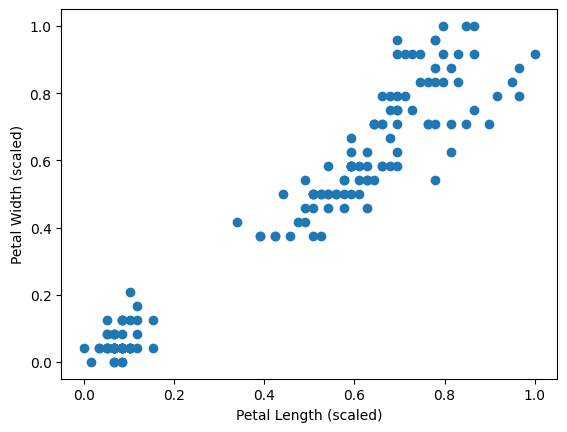

In [9]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')

KMeans after scaling

In [10]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])
df['cluster'] = y_predicted
df.head()

,petal length (cm),petal width (cm),flower_name,cluster
0,0.067797,0.041667,setosa,1
1,0.067797,0.041667,setosa,1
2,0.050847,0.041667,setosa,1
3,0.084746,0.041667,setosa,1
4,0.067797,0.041667,setosa,1


In [11]:
km.cluster_centers_

array([[0.7740113 , 0.81510417],
       [0.07830508, 0.06083333],
       [0.55867014, 0.51041667]])

Plot clusters after scaling

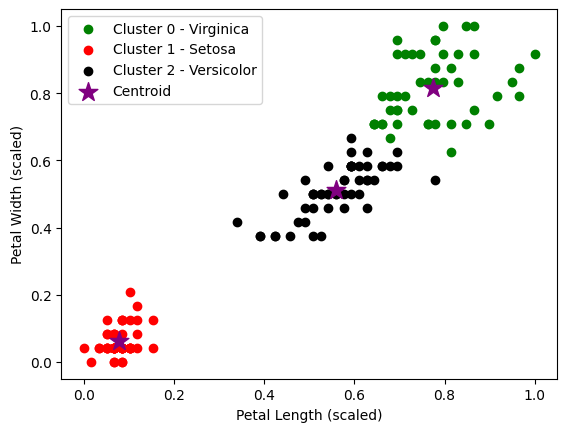

In [12]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='green', label='Cluster 0 - Virginica')
plt.scatter(df2['petal length (cm)'], df2['petal width (cm)'], color='red', label='Cluster 1 - Setosa')
plt.scatter(df3['petal length (cm)'], df3['petal width (cm)'], color='black', label='Cluster 2 - Versicolor')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            color='purple', marker='*', s=200, label='Centroid')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()

Elbow Plot (find optimal K)

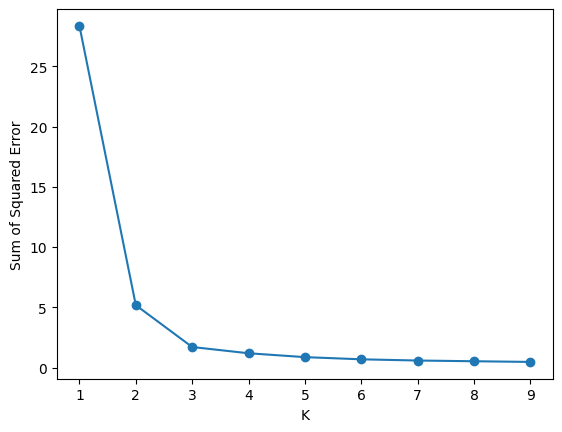

In [13]:
sse = []
k_rng = range(1, 10)

for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['petal length (cm)', 'petal width (cm)']])
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse, marker='o')